# Fase 2 — Limpieza de datos y Análisis Exploratorio (EDA)

**TP1 — Aprendizaje Automático (72.75) — ITBA** · Consignas **1.2** y **1.3**

Cubrimos los pasos **4 (Limpieza)** y **5 (EDA)** del pipeline de la Clase 3 (slide 16).

**Regla que gobierna todo el notebook: sólo miramos el train.** Todo lo que calculamos acá
—medias, cuartiles, IQR, correlaciones— son estadísticos. Calcularlos sobre el dataset
completo sería el data leakage que advierte la Clase 2 (slides 93–96). Por eso entramos por
`cargar_splits()` y nunca por `cargar_datos_crudos()`.

In [1]:
# ---------------------------------------------------------------------------
# Configuracion del entorno
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TARGET, FIGURES_DIR
from src.data import cargar_splits

# Funciones propias, documentadas en src/exploracion.py
from src.exploracion import (
    resumen_faltantes,   # cuenta nulos por columna
    limites_iqr,         # devuelve (limite_inferior, limite_superior) del criterio IQR
    outliers_iqr,        # mascara booleana de outliers segun IQR
    outliers_zscore,     # mascara booleana de outliers segun |z| > 3
    resumen_outliers,    # tabla comparativa de ambos criterios
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cargamos ambos conjuntos, pero el test NO se usa en este notebook.
train, _test_no_tocar = cargar_splits()

NUMERICAS = ["age", "bmi", "children"]
CATEGORICAS = ["sex", "smoker", "region"]

print(f"Train: {train.shape[0]} filas x {train.shape[1]} columnas | Target: {TARGET}")

Train: 1069 filas x 7 columnas | Target: charges


---

# Parte 1 — Limpieza de datos *(paso 4)*

La Clase 2 (slide 26) enumera tres problemas a revisar: **valores faltantes**, **outliers**
y **datos duplicados**. Los recorremos en ese orden, más un control de inconsistencias.

## 1.1 Valores faltantes *(consigna 1.2)*

Estrategias vistas en clase (Clase 2, slide 31):

| Estrategia | Cuándo se usa |
|---|---|
| Quitar la fila | Datasets grandes |
| Quitar la variable | Si la columna tiene mucho faltante (~20%) |
| Imputar | Media / mediana / moda, estadístico por grupo, o valor constante |

In [2]:
# resumen_faltantes() devuelve, por columna, cuantos nulos hay y su porcentaje.
faltantes = resumen_faltantes(train)
display(faltantes)

total_na = int(train.isna().sum().sum())
filas_completas = train.notna().all(axis=1).sum()
print(f"Total de valores faltantes: {total_na}")
print(f"Filas completas: {filas_completas} de {len(train)} ({filas_completas/len(train):.1%})")

,n_faltantes,pct_faltantes
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


Total de valores faltantes: 0
Filas completas: 1069 de 1069 (100.0%)


**Resultado: el dataset no tiene faltantes.** Ninguna de las 7 columnas tiene un solo
`NaN` en las 1069 filas del train.

**Decidimos no aplicar ninguna estrategia**, porque no hay nada que tratar: no eliminamos
filas, no descartamos variables y no imputamos valores.

Documentamos igual el análisis porque la consigna 1.2 pide mostrar que se verificó, no
asumirlo.

## 1.2 Datos duplicados

El dataset crudo tenía un par de filas idénticas (índices 195 y 581). **Ya las tratamos en
la Fase 1: eliminamos la copia repetida antes de separar train y test**, porque de lo
contrario una copia caía en train y la otra en test, y el test dejaba de contener datos
verdaderamente nuevos.

Volvemos a controlarlo acá para confirmar que no quedó ninguna.

In [3]:
# duplicated() marca las filas repetidas dentro del propio conjunto.
n_dup = train.duplicated().sum()
print(f"Filas exactamente duplicadas dentro del train: {n_dup}")

if n_dup:
    display(train[train.duplicated(keep=False)])
else:
    print("No hay filas repetidas: ya se eliminaron en la Fase 1, antes del split.")

Filas exactamente duplicadas dentro del train: 0
No hay filas repetidas: ya se eliminaron en la Fase 1, antes del split.


**Resultado: 0 duplicados.** El control confirma que la eliminación previa funcionó y
que no queda ninguna fila repetida en el train.

## 1.3 Inconsistencias

Distinguimos tres cosas que es fácil confundir:

| | Qué es | Ejemplo | Qué se hace |
|---|---|---|---|
| **Inconsistencia** | Valor **imposible**: viola una regla física o lógica | edad = -5, BMI = 0, costo negativo | Se corrige o se elimina |
| **Outlier** | Valor **raro pero posible** | costo de \$60.000 | Se analiza (sección 1.4) |
| **Fuera del rango de entrenamiento** | Valor posible que **no aparece en los datos** | una persona de 80 años | No se corrige: se documenta como límite del modelo |

Acá buscamos sólo lo primero. Los umbrales que usamos son **límites físicos**, no el rango
observado en el dataset: si usáramos el rango observado el control sería circular y nunca
podría fallar.

In [4]:
# Controles de valores IMPOSIBLES. Los umbrales son limites fisicos o logicos,
# deliberadamente amplios: buscamos errores de carga, no valores infrecuentes.
controles = {
    "age <= 0 o > 120": int(((train["age"] <= 0) | (train["age"] > 120)).sum()),
    "bmi <= 0 o > 100": int(((train["bmi"] <= 0) | (train["bmi"] > 100)).sum()),
    "children negativo": int((train["children"] < 0).sum()),
    f"{TARGET} <= 0": int((train[TARGET] <= 0).sum()),
    "categorias raras en sex": int((~train["sex"].isin(["male", "female"])).sum()),
    "categorias raras en smoker": int((~train["smoker"].isin(["yes", "no"])).sum()),
    "categorias raras en region": int((~train["region"].isin(
        ["northeast", "northwest", "southeast", "southwest"])).sum()),
}

print("--- Controles de valores imposibles ---")
for nombre, n in controles.items():
    print(f"  {nombre:<28}: {'OK' if n == 0 else f'REVISAR ({n})'}")

--- Controles de valores imposibles ---
  age <= 0 o > 120            : OK
  bmi <= 0 o > 100            : OK
  children negativo           : OK
  charges <= 0                : OK
  categorias raras en sex     : OK
  categorias raras en smoker  : OK
  categorias raras en region  : OK


**Resultado: sin inconsistencias.** Ningún valor imposible en ninguna columna.

### Rango de validez del modelo

Cosa distinta, y que sí conviene dejar anotada: **el rango que cubren los datos de
entrenamiento**. El modelo sólo aprende de lo que ve, así que predecir fuera de estos
rangos es **extrapolar** — la fórmula devuelve un número igual, pero sin respaldo empírico.

In [5]:
# Rango que cubre el entrenamiento. No es un control de errores:
# define hasta donde podemos confiar en las predicciones del modelo.
rangos = train[NUMERICAS + [TARGET]].agg(["min", "max"]).T
rangos.columns = ["minimo", "maximo"]
display(rangos.round(2))

print("Niveles observados en las variables categoricas:")
for col in CATEGORICAS:
    print(f"  {col:8s}: {sorted(train[col].unique())}")

,minimo,maximo
age,18.00,64.00
bmi,15.96,53.13
children,0.00,5.00
charges,1121.87,62592.87


Niveles observados en las variables categoricas:
  sex     : ['female', 'male']
  smoker  : ['no', 'yes']
  region  : ['northeast', 'northwest', 'southeast', 'southwest']


**Limitación que documentamos:** el train cubre edades de **18 a 64 años** y BMI de
**15.96 a 53.13**. Una persona de 80 años no es un dato erróneo — simplemente **no está
representada en el entrenamiento**, y la predicción del modelo para ese caso sería una
extrapolación sin respaldo.

Esto no se arregla limpiando datos: se arregla consiguiendo datos de esa población, o
declarando explícitamente el rango de aplicación del modelo. Lo retomamos en la Fase 6, al
responder qué RMSE esperar en datos nuevos.

**Decidimos no corregir ni eliminar ningún registro.**

## 1.4 Outliers *(consigna 1.3)*

Aplicamos los dos enfoques de la Clase 2:

- **Visuales** (slide 40): histogramas, boxplots y scatter plots.
- **Estadísticos** (slide 41): criterio IQR y criterio z-score (`|z| > 3`).

Usamos los dos porque, como dice la propia slide 40, los métodos visuales *"necesitan de un
estadístico para justificar la eliminación"*.

### 1.4.1 Histogramas

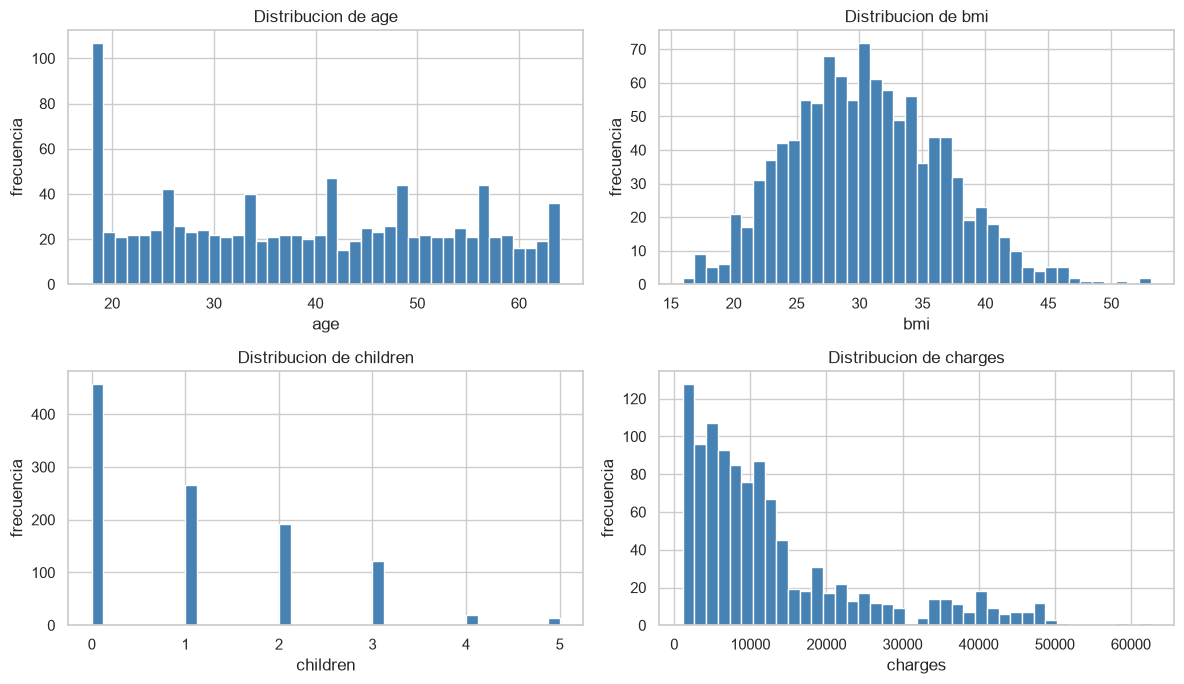

In [6]:
# Un histograma por variable numerica, para ver la forma de cada distribucion.
cols_plot = NUMERICAS + [TARGET]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, col in zip(axes.ravel(), cols_plot):
    ax.hist(train[col], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("frecuencia")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

- `age`: casi uniforme, sin cola extrema.
- `bmi`: aproximadamente simétrica, en forma de campana.
- `children`: discreta, concentrada en 0, 1 y 2.
- **`charges`: muy sesgada a la derecha y con dos "montañas".** Eso no es una cola: son
  **dos poblaciones** conviviendo en la misma variable (Clase 3, slides 37–38).

### 1.4.2 Boxplots

El boxplot dibuja los bigotes usando el criterio IQR, así que los puntos que marca son
exactamente los que detecta ese criterio (Clase 2, slide 40).

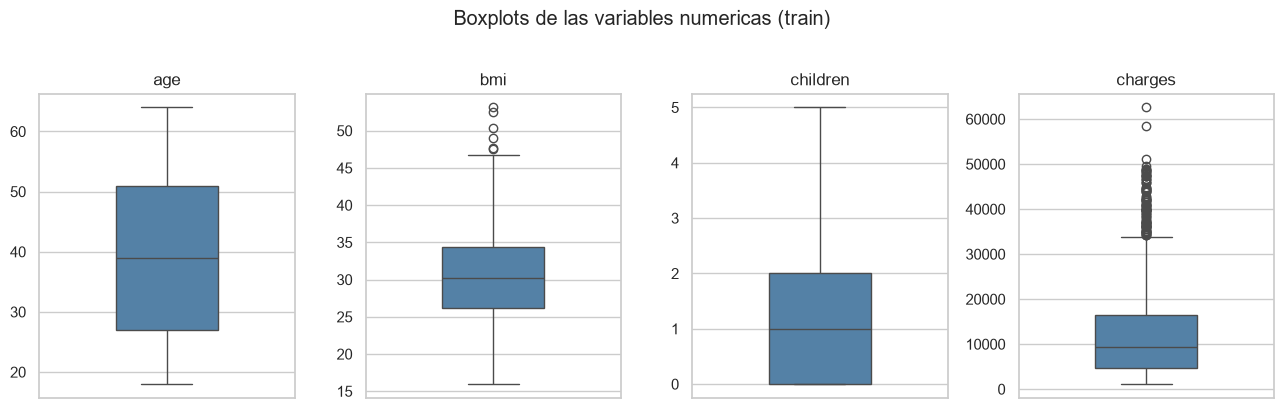

In [7]:
# Un boxplot por variable. Los puntos sueltos fuera de los bigotes son los outliers IQR.
fig, axes = plt.subplots(1, 4, figsize=(13, 4))

for ax, col in zip(axes, cols_plot):
    sns.boxplot(y=train[col], ax=ax, color="steelblue", width=0.4)
    ax.set_title(col)
    ax.set_ylabel("")

plt.suptitle("Boxplots de las variables numericas (train)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4.3 IQR vs z-score

In [8]:
# resumen_outliers() calcula ambos criterios para cada variable y los compara.
tabla_outliers = resumen_outliers(train, cols_plot)
tabla_outliers

,lim_inf_IQR,lim_sup_IQR,n_IQR,pct_IQR,n_zscore,pct_zscore
variable,,,,,,
age,-9.00,87.00,0,0.00,0,0.00
bmi,13.80,46.80,6,0.56,4,0.37
children,-3.00,5.00,0,0.00,14,1.31
charges,-12808.71,34006.66,106,9.92,11,1.03


**Los dos criterios no coinciden:**

| Variable | IQR | z-score | Qué son |
|---|---|---|---|
| `age` | 0 | 0 | Sin atípicos |
| `bmi` | 6 (0.6%) | 4 (0.4%) | Casos de obesidad severa |
| `children` | 0 | 14 (1.3%) | Personas con 5 hijos: valor legítimo |
| **`charges`** | **106 (9.9%)** | **11 (1.0%)** | **Diferencia grande** |

**Por qué difieren:** el z-score usa **media y desvío**, que no son robustos — los propios
valores extremos los inflan y el umbral se corre hacia afuera. El IQR usa **cuartiles**,
que sí son robustos, y por eso marca muchos más.

Que un criterio señale casi el **10%** de los datos como atípicos ya es sospechoso: si una
de cada diez observaciones es "rara", el problema probablemente no sean los datos sino el
supuesto de que hay una sola población.

### 1.4.4 ¿Qué son los outliers de `charges`?

El histograma mostró dos montañas, o sea **dos grupos de personas mezclados**. Antes de
decidir si eliminamos esos 106 registros, buscamos **qué variable separa esos dos grupos**.

No lo adivinamos: probamos las tres categóricas del dataset y vemos cuál divide a la
población entre "caros" y "baratos".

In [9]:
# Marcamos que filas son outliers del target segun el criterio IQR.
mask_out = outliers_iqr(train[TARGET])
outliers = train[mask_out]

print(f"Outliers de charges por IQR: {len(outliers)} filas ({mask_out.mean():.1%} del train)\n")

# Para cada variable categorica, medimos que porcentaje de cada uno de sus grupos
# cae en la zona de outliers. Si una variable separa bien las dos poblaciones,
# un grupo tendra un porcentaje muy alto y el otro muy bajo.
print("Que porcentaje de cada grupo cae en la zona de outliers:\n")
for col in CATEGORICAS:
    pct = (100 * train.groupby(col, observed=True).apply(
        lambda g: mask_out[g.index].mean(), include_groups=False)).round(1)
    print(f"-- {col} --")
    print(pct.to_string())
    print(f"   diferencia entre el grupo mas alto y el mas bajo: "
          f"{pct.max() - pct.min():.1f} puntos\n")

Outliers de charges por IQR: 106 filas (9.9% del train)

Que porcentaje de cada grupo cae en la zona de outliers:

-- sex --
sex
female     6.9
male      12.7
   diferencia entre el grupo mas alto y el mas bajo: 5.8 puntos

-- smoker --
smoker
no      0.4
yes    48.1
   diferencia entre el grupo mas alto y el mas bajo: 47.7 puntos

-- region --
region
northeast     8.3
northwest     4.5
southeast    15.3
southwest    10.9
   diferencia entre el grupo mas alto y el mas bajo: 10.8 puntos



**`smoker` es la única que separa.** En `sex` la diferencia entre grupos es de 5.8 puntos y
en `region` de 10.8: esas variables no distinguen caros de baratos. En `smoker` la
diferencia es de **47.7 puntos** — sólo el 0.4% de los no fumadores cae en la zona de
outliers, contra el 48.1% de los fumadores.

Confirmado eso, miramos la composición de los outliers.

In [10]:
# Comparamos cuantos outliers aporta cada grupo contra su tamano en el train.
comp = pd.DataFrame({
    "n_outliers": outliers["smoker"].value_counts(),
    "n_train": train["smoker"].value_counts(),
})
comp["% del grupo que es outlier"] = (100 * comp["n_outliers"] / comp["n_train"]).round(1)
display(comp)

print(f"% de fumadores dentro de los outliers: {(outliers['smoker'] == 'yes').mean():.1%}")
print(f"% de fumadores en el train completo  : {(train['smoker'] == 'yes').mean():.1%}")

,n_outliers,n_train,% del grupo que es outlier
smoker,,,
no,3,855,0.4
yes,103,214,48.1


% de fumadores dentro de los outliers: 97.2%
% de fumadores en el train completo  : 20.0%


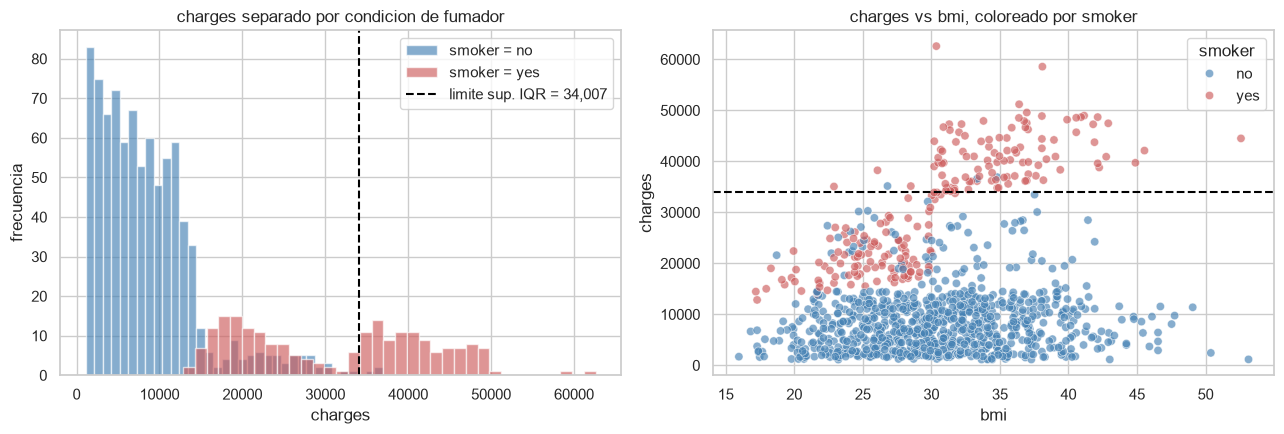

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
paleta = {"no": "steelblue", "yes": "indianred"}

# Izquierda: el mismo histograma de charges, pero separando por condicion de fumador.
for fuma, color in paleta.items():
    axes[0].hist(train.loc[train["smoker"] == fuma, TARGET], bins=35, alpha=0.65,
                 label=f"smoker = {fuma}", color=color)

# Marcamos el limite superior del criterio IQR: todo lo que queda a la derecha
# es lo que ese criterio llamaria "outlier".
_, limite_sup = limites_iqr(train[TARGET])
axes[0].axvline(limite_sup, color="black", linestyle="--", linewidth=1.5,
                label=f"limite sup. IQR = {limite_sup:,.0f}")
axes[0].set_title("charges separado por condicion de fumador")
axes[0].set_xlabel("charges")
axes[0].set_ylabel("frecuencia")
axes[0].legend()

# Derecha: scatter plot, el tercer metodo visual de la Clase 2.
sns.scatterplot(data=train, x="bmi", y=TARGET, hue="smoker", alpha=0.65,
                palette=paleta, ax=axes[1])
axes[1].axhline(limite_sup, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title("charges vs bmi, coloreado por smoker")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_charges_por_smoker.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Cuantificamos el costo de eliminar esos outliers.
fumadores = train["smoker"] == "yes"
fumadores_perdidos = int((mask_out & fumadores).sum())

print("SI ELIMINARAMOS LOS OUTLIERS DE charges POR IQR:")
print(f"  se irian {mask_out.sum()} filas de {len(train)} ({mask_out.mean():.1%} del train)")
print(f"  de ellas, {fumadores_perdidos} son fumadores")
print(f"  perderiamos el {fumadores_perdidos / fumadores.sum():.1%} de TODOS los fumadores")
print(f"  la proporcion de fumadores caeria de {fumadores.mean():.1%} a "
      f"{(fumadores & ~mask_out).sum() / (~mask_out).sum():.1%}")

SI ELIMINARAMOS LOS OUTLIERS DE charges POR IQR:
  se irian 106 filas de 1069 (9.9% del train)
  de ellas, 103 son fumadores
  perderiamos el 48.1% de TODOS los fumadores
  la proporcion de fumadores caeria de 20.0% a 11.5%


**Los 106 "outliers" son fumadores en un 97.2%.** Visto al revés: el **48% de todos los
fumadores** del train cae fuera del límite IQR.

Los gráficos lo confirman: la bimodalidad de `charges` **es** la separación entre fumadores
y no fumadores, y los puntos por encima de la línea no son ruido disperso sino una
estructura ordenada que crece con el `bmi`.

### 1.4.5 Decisión sobre los outliers

Estrategias vistas en clase (Clase 2, slide 42): **eliminar el dato**, **transformar** para
reducir su efecto, o **usar modelos más robustos**.

---

**Decidimos mantener todos los registros. No eliminamos ninguna fila por outlier.**

**Motivos:**

1. **No son errores.** El control de consistencia no encontró ningún valor imposible. Un
   costo de \$50.000 para un fumador con obesidad es perfectamente plausible.
2. **Son la señal principal, no ruido.** Eliminarlos borraría la mitad de los fumadores del
   train y dejaría un modelo incapaz de predecir el segmento más caro — justo el que más le
   importa a una aseguradora.
3. **El criterio IQR no aplica acá.** Asume una distribución unimodal, y `charges` es
   bimodal. Está midiendo la distancia entre dos poblaciones, no la rareza dentro de una.
4. **`charges` es el target, no una feature.** El criterio de la clase apunta a las
   variables de entrada. Recortar el target cambiaría el problema: pasaríamos de predecir
   "el costo médico" a predecir "el costo médico de los casos baratos".

**`bmi`:** los 6 casos entre 47.5 y 53.1 son obesidad severa, y su costo medio (\$12.886)
es casi igual al del resto del train (\$13.031). **Se mantienen.**

**`children`:** los 14 que marca el z-score son personas con 5 hijos. **Se mantienen.**

---

**Las otras dos estrategias de la slide 42 sí las aplicamos, más adelante:**

- **Modelos robustos** → la regularización L1 de la Fase 5 limita cuánto puede el modelo
  dejarse arrastrar por valores extremos.
- **Transformaciones** → evaluamos en la Fase 3 una transformación logarítmica de `charges`.

En lugar de eliminar los valores extremos, le damos al modelo la variable que los explica:
`smoker` entra como feature. Es lo que sugiere la Clase 3 (slide 38) al recomendar crear
una variable que identifique la población — sólo que acá esa variable ya existe.

---

# Parte 2 — Análisis Exploratorio *(paso 5)*

Objetivos del EDA según la Clase 3 (slide 33): detectar problemas *(hecho en la Parte 1)*,
entender las variables y descubrir relaciones entre ellas.

## 2.1 Estadísticas descriptivas

In [13]:
# describe() da count, media, desvio, minimo, cuartiles y maximo.
# .T transpone para leer una variable por fila.
display(train[NUMERICAS + [TARGET]].describe().T.round(2))

# Para las categoricas mostramos el peso relativo de cada nivel.
print("Distribucion de las categoricas (%):")
for col in CATEGORICAS:
    print(f"\n-- {col} --")
    print((100 * train[col].value_counts(normalize=True)).round(1).to_string())

,count,mean,std,min,25%,50%,75%,max
age,1069.0,39.20,14.00,18.00,27.00,39.00,51.00,64.00
bmi,1069.0,30.54,6.05,15.96,26.18,30.20,34.43,53.13
children,1069.0,1.08,1.19,0.00,0.00,1.00,2.00,5.00
charges,1069.0,13030.20,11706.53,1121.87,4747.05,9290.14,16450.89,62592.87


Distribucion de las categoricas (%):

-- sex --
sex
male      51.4
female    48.6

-- smoker --
smoker
no     80.0
yes    20.0

-- region --
region
southeast    26.8
southwest    24.8
northwest    24.7
northeast    23.7


Un dato de `charges`: la **media (\$13.030) supera a la mediana (\$9.290) en un 40%**.
Esa brecha es la marca de una cola derecha pesada — el promedio está siendo empujado por el
grupo de costos altos.

## 2.2 Relación de cada variable con el target

*"En regresión → correlación de las variables con y"* (Clase 3, slide 48).

In [14]:
# Correlacion de Pearson de cada variable numerica contra el target.
corr_target = train[NUMERICAS + [TARGET]].corr()[TARGET].drop(TARGET)
print("Correlacion de Pearson con charges:")
print(corr_target.sort_values(ascending=False).round(3).to_string())

Correlacion de Pearson con charges:
age         0.290
bmi         0.178
children    0.086


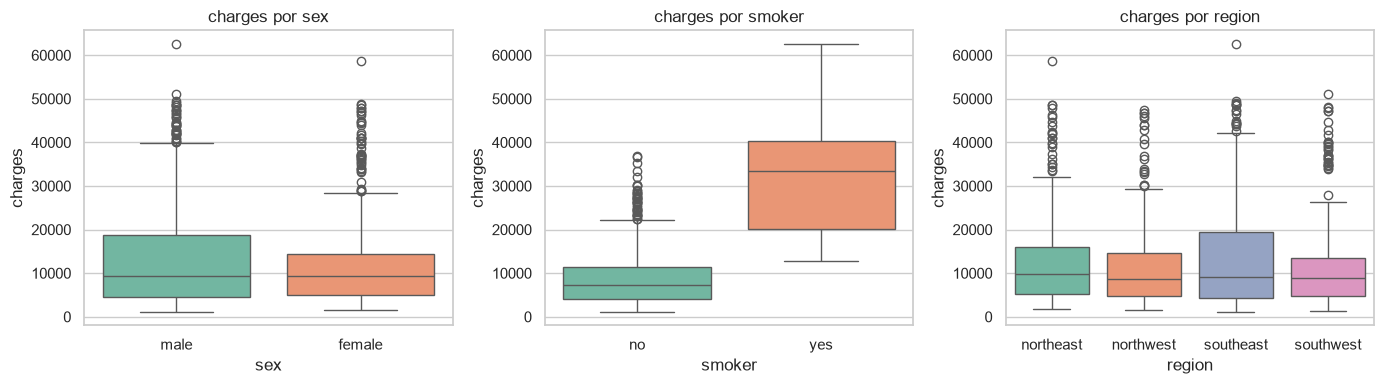

Media y mediana de charges por categoria:

-- sex --
        count     mean  median
sex                           
female    519  12305.0  9411.0
male      550  13714.0  9289.0

-- smoker --
        count     mean   median
smoker                         
no        855   8498.0   7348.0
yes       214  31136.0  33392.0

-- region --
           count     mean  median
region                           
northeast    253  13241.0  9876.0
northwest    264  11907.0  8749.0
southeast    287  14555.0  9059.0
southwest    265  12296.0  8968.0


In [15]:
# Para las categoricas usamos boxplots: comparan la distribucion del target
# entre los niveles de cada variable.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, CATEGORICAS):
    sns.boxplot(data=train, x=col, y=TARGET, ax=ax, palette="Set2", hue=col, legend=False)
    ax.set_title(f"charges por {col}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_charges_por_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

print("Media y mediana de charges por categoria:")
for col in CATEGORICAS:
    print(f"\n-- {col} --")
    print(train.groupby(col)[TARGET].agg(["count", "mean", "median"]).round(0).to_string())

**Este es el hallazgo central del EDA:**

| Variable | Relación con `charges` |
|---|---|
| `age` | Pearson **0.290** (débil) |
| `bmi` | Pearson **0.178** (débil) |
| `children` | Pearson **0.086** (casi nula) |
| `sex` | \$12.305 vs \$13.714 → diferencia chica |
| `region` | entre \$11.907 y \$14.555 → diferencia chica |
| **`smoker`** | **\$8.498 vs \$31.136 → 3.7×** |

Ninguna variable numérica llega a 0.3 de correlación, y sin embargo el problema **sí** es
predecible: lo que manda es una variable **categórica**.

Esto muestra en vivo la advertencia de la Clase 3 (slide 65): Pearson *"únicamente capta
relaciones lineales"* y sólo aplica a numéricas. Si nos guiáramos sólo por Pearson,
concluiríamos que el problema es casi impredecible, y estaríamos equivocados.

> Por eso en la Fase 3 agregamos **información mutua** (Clase 3, slide 66), que detecta
> relaciones no lineales y funciona con cualquier tipo de variable.

## 2.3 ¿Hay features redundantes?

*"Variables con alta correlación contienen información muy similar y son probablemente
redundantes"* (Clase 3, slide 55).

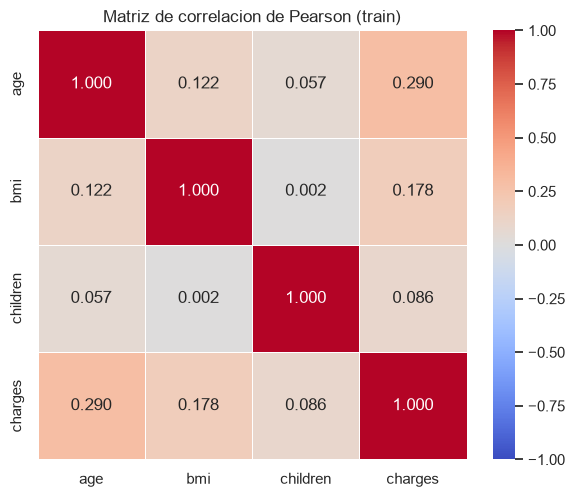

Correlacion absoluta maxima entre features: 0.122 (age - bmi)


In [16]:
# Matriz de correlacion de Pearson entre todas las numericas y el target.
corr_matrix = train[NUMERICAS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matriz de correlacion de Pearson (train)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Buscamos la correlacion mas alta ENTRE features, ignorando la diagonal (que vale 1).
entre_features = corr_matrix.loc[NUMERICAS, NUMERICAS].abs()
sin_diagonal = entre_features.where(~np.eye(len(NUMERICAS), dtype=bool))
var_a, var_b = sin_diagonal.stack().idxmax()
print(f"Correlacion absoluta maxima entre features: {sin_diagonal.max().max():.3f} "
      f"({var_a} - {var_b})")

**No hay redundancia.** La correlación máxima entre features es **0.122**, muy lejos de
cualquier umbral que justifique descartar una variable.

Tampoco hay problema de dimensionalidad: con 6 variables y 1069 filas, la "regla del 10×"
(Clase 2, slide 91) pediría unas 60 observaciones. **Decidimos conservar todas las
features**; lo formalizamos en la Fase 3.

## 2.4 La interacción `smoker` × `bmi`

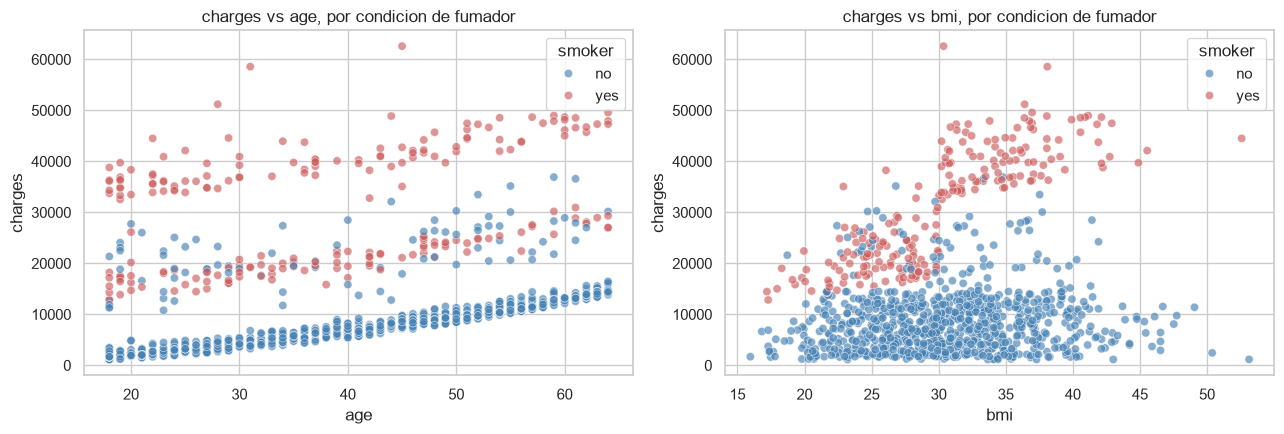

In [17]:
# Scatter plots del target contra las dos numericas mas relevantes,
# coloreando por smoker para ver si el efecto cambia entre grupos.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
paleta = {"no": "steelblue", "yes": "indianred"}

for ax, col in zip(axes, ["age", "bmi"]):
    sns.scatterplot(data=train, x=col, y=TARGET, hue="smoker", palette=paleta,
                    alpha=0.65, ax=ax)
    ax.set_title(f"charges vs {col}, por condicion de fumador")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_scatter_target.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Calculamos la correlacion por separado dentro de cada grupo.
# Si los valores difieren mucho, hay interaccion.
filas = []
for fuma in ["no", "yes"]:
    sub = train[train["smoker"] == fuma]
    filas.append({
        "smoker": fuma,
        "n": len(sub),
        "corr_age": round(sub["age"].corr(sub[TARGET]), 3),
        "corr_bmi": round(sub["bmi"].corr(sub[TARGET]), 3),
    })
pd.DataFrame(filas).set_index("smoker")

,n,corr_age,corr_bmi
smoker,,,
no,855,0.610,0.086
yes,214,0.348,0.809


**Lo que muestran los gráficos:**

- En `charges` vs `age` se ven **bandas paralelas** que suben con la edad: la relación
  existe, pero está desplazada verticalmente según `smoker`.
- En `charges` vs `bmi` el contraste es más fuerte: entre **no fumadores** el costo casi no
  depende del `bmi` (nube plana); entre **fumadores** crece de forma marcada. La
  correlación por grupo lo confirma.

Comparando la correlación global con la calculada dentro de cada grupo:

| | Mezclando todo | No fumadores | Fumadores |
|---|---|---|---|
| `bmi` | 0.178 | 0.086 | **0.809** |
| `age` | 0.290 | **0.610** | 0.348 |

`bmi` pasa de 0.178 a **0.809** entre fumadores: más de cuatro veces. Y entre no fumadores
casi no importa (0.086). Al mezclar dos grupos que se comportan distinto, los efectos se
promedian y queda un 0.178 que **no describe a ninguno de los dos**.

Es decir: **el efecto de `bmi` depende del valor de `smoker`**. Eso se llama
**interacción**, y un modelo lineal simple —que suma efectos independientes— no puede
representarla: tiene un único coeficiente para `bmi`, igual para todo el mundo.

> **Acá está la justificación real de la regresión polinómica de la Fase 5.** Los términos
> cruzados que genera `PolynomialFeatures` (por ejemplo `bmi × smoker`) son exactamente lo
> que hace falta. No aplicamos la transformación porque el enunciado la pide, sino porque
> el EDA muestra que hace falta.

---

## Conclusiones de la Fase 2

### Limpieza *(paso 4)*

| Problema | Hallazgo | Decisión |
|---|---|---|
| Faltantes | 0 en las 7 columnas | No aplicamos ninguna estrategia |
| Duplicados | 0 (eliminados en la Fase 1, antes del split) | Control confirmado |
| Inconsistencias | Ninguna | No corregimos ningún registro |
| Outliers `charges` | 106 por IQR (9.9%), 97.2% fumadores | **Se mantienen**: son la señal, no ruido |
| Outliers `bmi` | 6 por IQR: obesidad severa | **Se mantienen** |
| Outliers `children` | 14 por z-score: 5 hijos | **Se mantienen** |

### EDA *(paso 5)*

1. `charges` es **bimodal y asimétrica**; la bimodalidad se explica por `smoker`.
2. Ninguna numérica correlaciona fuerte con el target (máx. 0.290). El predictor dominante
   es **categórico**.
3. **No hay redundancia** entre features (máx. 0.122) ni problema de dimensionalidad.
4. Existe una **interacción `smoker` × `bmi`** que un modelo lineal no captura.

### Qué queda para las fases siguientes

- **Fase 3:** encoding de categóricas, escalado z-score, información mutua y evaluación de
  una transformación logarítmica del target.
- **Fase 5:** la regresión polinómica, como respuesta a la interacción detectada acá.

**Siguiente:** Fase 3 — Preprocesamiento y features (paso 6, consignas 1.1 y 1.4).